In [10]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from tensorflow.data import Dataset

In [11]:
DATASET_DIR = "./Dataset"

images = []
for filename in os.listdir(DATASET_DIR):
    img = load_img(f"{DATASET_DIR}/{filename}", target_size=(64, 64))
    img = img_to_array(img)
    images.append(img)

In [12]:
images = np.asarray(images).astype(np.float32) / 255.0

total = len(images)
split = int(total * 0.8)

x_train = images[:split]
x_test = images[split:]

IMAGE_ORIGINAL_SHAPE = images.shape[1:]
IMAGE_SIZE = IMAGE_ORIGINAL_SHAPE[0] * IMAGE_ORIGINAL_SHAPE[1] * IMAGE_ORIGINAL_SHAPE[2]

EPOCHS = 5
BATCH_SIZE = 10
LATENT_DIM = 32
HIDDEN_DIM_256 = 256
HIDDEN_DIM_512 = 512
LEARNING_RATE = 0.0001

In [13]:
class VAE(Model):
    def __init__(self, h_dim_256, h_dim_512, l_dim, **kwargs):
        super(VAE, self).__init__(**kwargs)

        self.enc_de_1 = Dense(h_dim_512)
        self.enc_bn_1 = BatchNormalization()
        self.enc_do_1 = Dropout(0.2)
        self.enc_de_2 = Dense(h_dim_256)
        self.enc_bn_2 = BatchNormalization()
        self.enc_do_2 = Dropout(0.2)

        self.mu = Dense(l_dim)
        self.log_var = Dense(l_dim)

        self.dec_de_1 = Dense(h_dim_256)
        self.dec_bn_1 = BatchNormalization()
        self.dec_do_1 = Dropout(0.2)
        self.dec_de_2 = Dense(h_dim_512)
        self.dec_bn_2 = BatchNormalization()
        self.dec_de_out = Dense(IMAGE_SIZE)
        self.dec_bn_out = BatchNormalization()

    def encode(self, x):
        x = self.enc_de_1(x)
        x = self.enc_bn_1(x)
        x = self.enc_do_1(x)
        x = self.enc_de_2(x)
        x = self.enc_bn_2(x)
        x = self.enc_do_2(x)
        return self.mu(x), self.log_var(x)
    
    def reparam(self, mu, log_var):
        std = tf.exp(log_var * 0.5)
        exp = tf.random.normal(std.shape)
        return mu + std * exp
    
    def decode_logits(self, z):
        z = self.dec_de_1(z)
        z = self.dec_bn_1(z)
        z = self.dec_do_1(z)
        z = self.dec_de_2(z)
        z = self.dec_bn_2(z)
        z = self.dec_de_out(z)
        return self.dec_bn_out(z)
    
    def decode(self, z):
        return tf.nn.sigmoid(self.decode_logits(z))
    
    def call(self, input):
        mu, log_var = self.encode(input)
        z = self.reparam(mu, log_var)
        x_recon_logits = self.decode_logits(z)
        return x_recon_logits, mu, log_var

In [14]:
model = VAE(HIDDEN_DIM_256, HIDDEN_DIM_512, LATENT_DIM)
model(tf.zeros((BATCH_SIZE, IMAGE_SIZE)))
model.summary()

Model: "vae_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (10, 512)              │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (10, 512)              │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (10, 256)              │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (10, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (10, 32)               │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (10, 32)               │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (10, 256)              │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (10, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (10, 512)              │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (10, 512)              │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (10, 12288)            │     6,303,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (10, 12288)            │        49,152 │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,816 (49.36 MB)

 Trainable params: 12,911,168 (49.25 MB)

 Non-trainable params: 27,648 (108.00 KB)

In [15]:
dataset = Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(BATCH_SIZE * 5).batch(BATCH_SIZE)
optimizer = Adam(LEARNING_RATE)

In [26]:
loss_history = []
kl_div_history = []

for epoch in range(EPOCHS):
    for x in dataset:
        x = tf.reshape(x, (-1, IMAGE_SIZE))
        with tf.GradientTape() as tape:
            x_recon_logits, mu, log_var = model(x)
            recon_loss = tf.nn.sigmoid_cross_entropy_with_logits(x, x_recon_logits)
            recon_loss = tf.reduce_mean(tf.reduce_sum(recon_loss, axis=1))

            kl_div = -0.5 * tf.reduce_sum(1 + log_var - tf.exp(log_var) - tf.square(mu), axis=1)
            kl_div = tf.reduce_mean(kl_div)
            loss = recon_loss + kl_div

        gradients = tape.gradient(loss, model.trainable_variables)
        gradients = [tf.clip_by_norm(g, 15) for g in gradients]
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    print(f"Epoch [{epoch+1}/{EPOCHS}]: recon_loss: {recon_loss:.2f} | KLDiv: {kl_div:.2f} | loss: {loss:.2f}")
    loss_history.append(recon_loss)
    kl_div_history.append(kl_div)

Epoch [0/5]: recon_loss: 7157.95 | KLDiv: 124.49 | loss: 7282.44
Epoch [1/5]: recon_loss: 6761.16 | KLDiv: 68.55 | loss: 6829.71
Epoch [2/5]: recon_loss: 7007.15 | KLDiv: 39.94 | loss: 7047.09
Epoch [3/5]: recon_loss: 6667.69 | KLDiv: 63.36 | loss: 6731.05
Epoch [4/5]: recon_loss: 6643.19 | KLDiv: 57.69 | loss: 6700.87


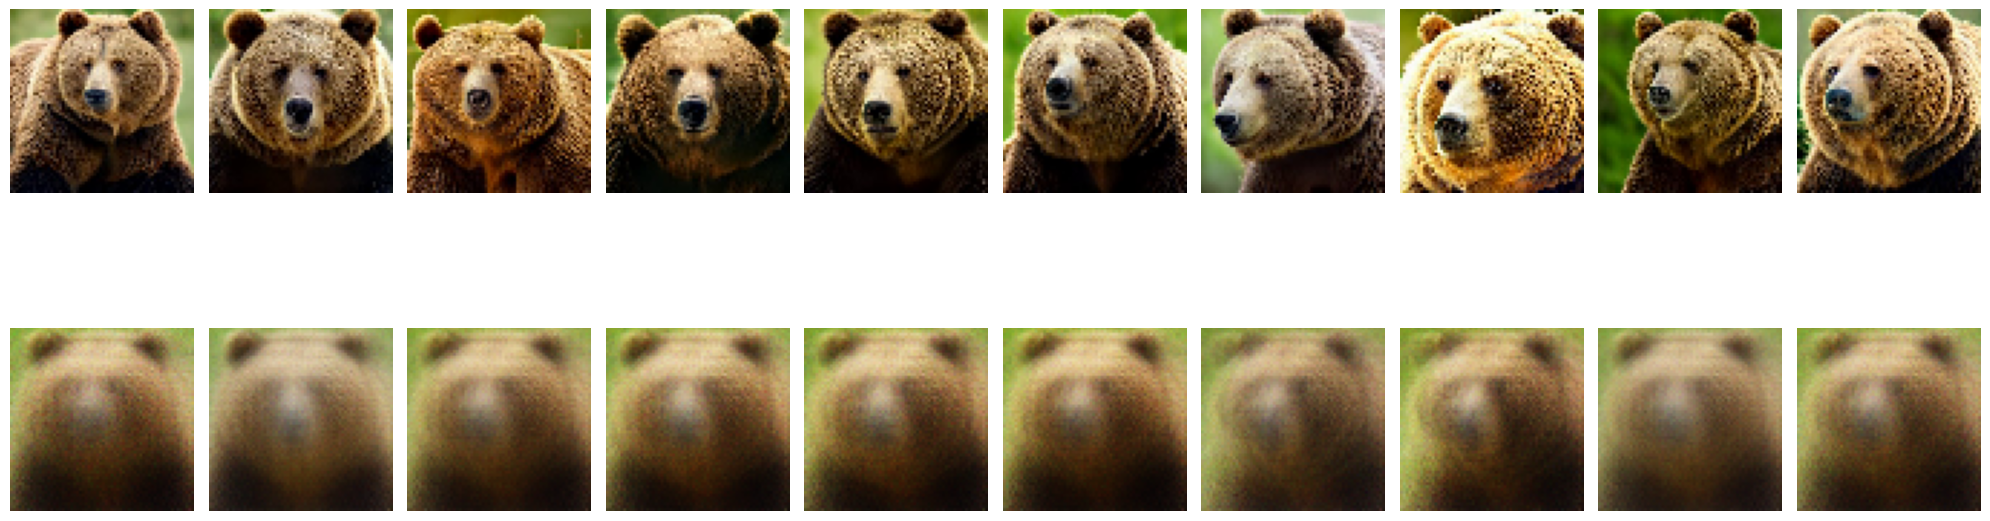

In [34]:
mu, log_var = model.encode(x_test.reshape(-1, IMAGE_SIZE))
z = model.reparam(mu, log_var)
out = model.decode(z)
out = tf.reshape(out, [-1, IMAGE_ORIGINAL_SHAPE[0], IMAGE_ORIGINAL_SHAPE[1], IMAGE_ORIGINAL_SHAPE[2]])

num = 10
plt.figure(figsize=(20, 8))
for i in range(num):
    plt.subplot(2, num, i+1)
    plt.imshow(x_test[i])
    plt.axis("off")
    plt.subplot(2, num, num+i+1)
    plt.imshow(out[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

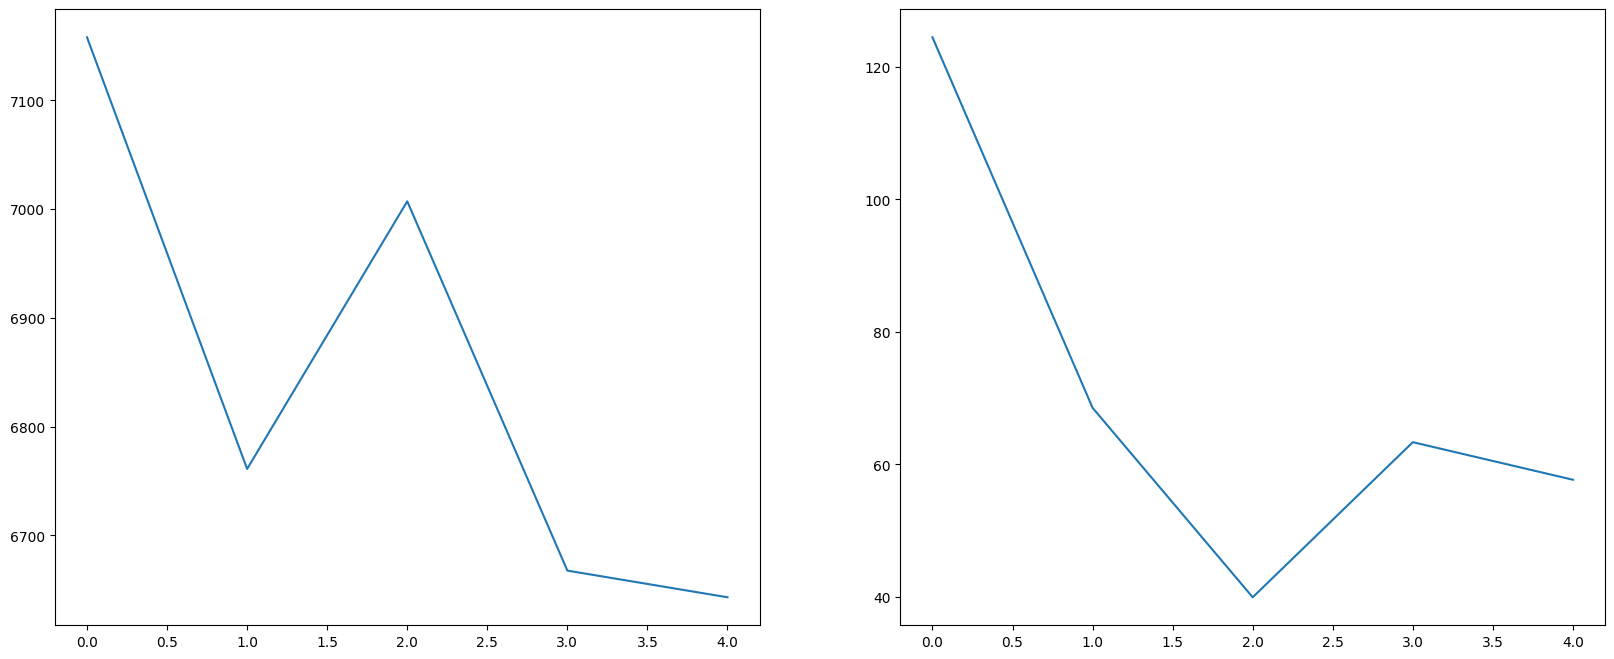

In [36]:
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.subplot(1, 2, 2)
plt.plot(kl_div_history)
plt.show()